In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('final4.csv')

In [3]:
df.head()

,index,verbatimScientificName,stateProvince,individualCount,decimalLatitude,decimalLongitude,eventDate,avg_rad,cf_cvg,NDVI_raw,...,SSSMASS,TOTEXTTAU,TOTSCATAU,temp_mean,temp_max,temp_min,rainfall,wind_mean,humid_mean,shortwave_radiation
0,0,Anarhynchus alexandrinus,Mannar,8.0,9.058512,79.855020,2021-01-06,0.66,5.0,3792.0,...,3.725563e-08,0.175115,0.165737,26.58,28.52,24.74,15.17,1.31,85.53,17.65
1,1,Columba livia,Colombo,31.0,6.927894,79.865005,2024-09-24,25.40,1.0,5692.0,...,5.924096e-08,0.191869,0.184795,27.52,29.55,26.03,2.63,5.50,84.41,20.77
2,2,Hirundo rustica,Colombo,10.0,6.866285,79.931440,2024-12-23,10.16,7.0,7045.0,...,3.249729e-08,0.198127,0.187366,26.21,28.84,24.10,0.25,2.51,84.30,20.49
3,3,Geokichla spiloptera,Matale,1.0,7.401229,80.690730,2024-09-13,1.13,1.0,9506.0,...,3.795434e-08,0.162928,0.156176,27.29,32.96,23.45,0.17,4.11,76.89,22.42
4,4,Himantopus himantopus,Puttalam,6.0,8.154166,79.736084,2024-11-28,0.79,2.0,NaN,...,4.148581e-08,0.213164,0.203239,25.86,27.55,24.85,0.99,6.15,84.07,8.78


In [4]:
df.shape

(1998917, 28)

In [5]:
df.columns

Index(['index', 'verbatimScientificName', 'stateProvince', 'individualCount',
       'decimalLatitude', 'decimalLongitude', 'eventDate', 'avg_rad', 'cf_cvg',
       'NDVI_raw', 'LandCover_Class', 'elevation_meters', 'BCSMASS',
       'DUEXTT25', 'DUSMASS', 'OCSMASS', 'SO2SMASS', 'SO4SMASS', 'SSSMASS',
       'TOTEXTTAU', 'TOTSCATAU', 'temp_mean', 'temp_max', 'temp_min',
       'rainfall', 'wind_mean', 'humid_mean', 'shortwave_radiation'],
      dtype='object')

In [6]:
cols = [
    "individualCount", "NDVI_raw", "LandCover_Class",
    "verbatimScientificName", "decimalLatitude", "decimalLongitude", 'eventDate'
]

d = df[cols].copy()
d["NDVI"] = pd.to_numeric(d["NDVI_raw"], errors="coerce") / 10000

### NDVI_raw - Raw Normalized Difference Vegetation Index (scaled for storage)	Dimensionless (-10000 to +10000)
### NDVI - True calculated vegetation greenness (NDVI_raw / 10000)	Dimensionless (-1.0 to 1.0)

In [8]:
# < 0.0: Deep water bodies, oceans, or severe cloud interference.
# 0.0 to 0.1: Barren areas of rock, sand, snow, or dense concrete (Urban cores).
# 0.2 to 0.4: Sparse vegetation, dry scrublands, or bare soil.
# 0.5 to 0.7: Moderate vegetation, active agricultural croplands, or mixed forests.
# 0.8 to 1.0: Dense, healthy, wet canopy vegetation (e.g., Evergreen Rainforests).

In [7]:
d.head()

,individualCount,NDVI_raw,LandCover_Class,verbatimScientificName,decimalLatitude,decimalLongitude,eventDate,NDVI
0,8.0,3792.0,10,Anarhynchus alexandrinus,9.058512,79.855020,2021-01-06,0.3792
1,31.0,5692.0,13,Columba livia,6.927894,79.865005,2024-09-24,0.5692
2,10.0,7045.0,13,Hirundo rustica,6.866285,79.931440,2024-12-23,0.7045
3,1.0,9506.0,8,Geokichla spiloptera,7.401229,80.690730,2024-09-13,0.9506
4,6.0,NaN,11,Himantopus himantopus,8.154166,79.736084,2024-11-28,NaN


In [9]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1998917 entries, 0 to 1998916
Data columns (total 8 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   individualCount         float64
 1   NDVI_raw                float64
 2   LandCover_Class         int64  
 3   verbatimScientificName  object 
 4   decimalLatitude         float64
 5   decimalLongitude        float64
 6   eventDate               object 
 7   NDVI                    float64
dtypes: float64(5), int64(1), object(2)
memory usage: 122.0+ MB


In [10]:
d.isnull().sum()

individualCount               0
NDVI_raw                  81102
LandCover_Class               0
verbatimScientificName        0
decimalLatitude               0
decimalLongitude              0
eventDate                     0
NDVI                      81102
dtype: int64

In [11]:
# As there are 81102 null values in NDVI, we will drop those rows for our analysis
d = d.dropna(subset=["NDVI"])

In [12]:
d.shape

(1917815, 8)

In [13]:
d.isnull().sum()

individualCount           0
NDVI_raw                  0
LandCover_Class           0
verbatimScientificName    0
decimalLatitude           0
decimalLongitude          0
eventDate                 0
NDVI                      0
dtype: int64

### Correlation between individualCount and NDVI

##### pearsonr - Measures linear correlation between two variables
##### spearmanr - Measures rank/monotonic correlation

In [15]:
from scipy.stats import pearsonr, spearmanr, kruskal

r_p, p_p = pearsonr(d["individualCount"], d["NDVI"])
r_s, p_s = spearmanr(d["individualCount"], d["NDVI"])

# r_p → correlation value
# p_p → p-value (statistical significance)

print("Count vs NDVI")
print(f"Pearson r = {r_p:.3f}, p = {p_p:.4g}")
print(f"Spearman rho = {r_s:.3f}, p = {p_s:.4g}")

Count vs NDVI
Pearson r = -0.020, p = 3.438e-173
Spearman rho = -0.083, p = 0


### --------------------------------
##### Pearson correlation showed a very weak negative relationship between NDVI and individual count (r = −0.020, p < 0.001). Spearman correlation also indicated a weak negative association (ρ = −0.083, p < 0.001). Despite statistical significance due to the large sample size, the effect size is negligible, suggesting NDVI alone is not a strong predictor of individual abundance.
### --------------------------------

##### As NDVI data alone does not have any significant correlation, lets use LandCover_Class also to see the correlation with vegetation and bird count.

##### Here there are 17 landcover classes,
 ##### 1     Evergreen Needleleaf Forest      
 ##### 2     Evergreen Broadleaf Forest       
 ##### 3     Deciduous Needleleaf Forest        
 ##### 4     Deciduous Broadleaf Forest         
 ##### 5     Mixed Forest                       
 ##### 6     Closed Shrublands                  
 ##### 7     Open Shrublands                  
 ##### 8     Woody Savannas                   
 ##### 9     Savannas                         
 ##### 10    Grasslands                      
 ##### 11    Permanent Wetlands               
 ##### 12    Croplands                        
 ##### 13    Urban and Built-up             
 ##### 14    Cropland/Natural Vegetation Mosaic 
 ##### 15    Snow and Ice                     
 ##### 16    Barren or Sparsely Vegetated    
 ##### 17    Water Bodies 

In [18]:
# Count differences across land cover classes

# This code groups the dataset by land cover class and collects the corresponding 
# individualCount values for each group. It then applies the non-parametric Kruskal–Wallis 
# test using SciPy to determine whether the distribution of individual counts differs 
# significantly among the different land cover classes. The test returns the statistic 
# H and a p-value indicating statistical significance.

# Kruskal–Wallis Test - It compares the median (typical value) of several groups to see if at 
# least one group is significantly different from the others.


lc_groups = [g["individualCount"].values for _, g in d.groupby("LandCover_Class") if len(g) > 1]
if len(lc_groups) >= 2:
    H, p_kw = kruskal(*lc_groups)
    print(f"Kruskal-Wallis for count across LandCover_Class: H = {H:.3f}, p = {p_kw:.4g}")


Kruskal-Wallis for count across LandCover_Class: H = 22315.640, p = 0


##### The number of individuals is significantly different across different LandCover_Class categories, meaning some land cover types have higher or lower counts than others.

### Biodiversity vs vegetation (NDVI, LandCover_Class)

In [19]:
from scipy.stats import spearmanr, kruskal

In [20]:
d_bio = d[["verbatimScientificName", "NDVI", "LandCover_Class", "decimalLatitude", "decimalLongitude", "eventDate"]].copy()
d_bio["NDVI"] = pd.to_numeric(d_bio["NDVI"], errors="coerce")
d_bio["eventDate"] = pd.to_datetime(d_bio["eventDate"], errors="coerce")
d_bio = d_bio.dropna()

d_bio.head()

,verbatimScientificName,NDVI,LandCover_Class,decimalLatitude,decimalLongitude,eventDate
0,Anarhynchus alexandrinus,0.3792,10,9.058512,79.855020,2021-01-06
1,Columba livia,0.5692,13,6.927894,79.865005,2024-09-24
2,Hirundo rustica,0.7045,13,6.866285,79.931440,2024-12-23
3,Geokichla spiloptera,0.9506,8,7.401229,80.690730,2024-09-13
5,Corvus macrorhynchos,0.6989,10,5.983496,80.525480,2024-10-12


In [22]:
# Sampling unit: site + month (avoids pooling everything at site level only)
d_bio["site"] = d_bio["decimalLatitude"].round(3).astype(str) + "_" + d_bio["decimalLongitude"].round(3).astype(str)
d_bio["year_month"] = d_bio["eventDate"].dt.to_period("M").astype(str)
d_bio["sample_unit"] = d_bio["site"] + "_" + d_bio["year_month"]

d_bio.head()

# The code creates a unique sampling unit based on location (site) and time (month) so that biodiversity
# observations are analyzed at the site-month level instead of pooling all data from a site together.

,verbatimScientificName,NDVI,LandCover_Class,decimalLatitude,decimalLongitude,eventDate,site,year_month,sample_unit
0,Anarhynchus alexandrinus,0.3792,10,9.058512,79.855020,2021-01-06,9.059_79.855,2021-01,9.059_79.855_2021-01
1,Columba livia,0.5692,13,6.927894,79.865005,2024-09-24,6.928_79.865,2024-09,6.928_79.865_2024-09
2,Hirundo rustica,0.7045,13,6.866285,79.931440,2024-12-23,6.866_79.931,2024-12,6.866_79.931_2024-12
3,Geokichla spiloptera,0.9506,8,7.401229,80.690730,2024-09-13,7.401_80.691,2024-09,7.401_80.691_2024-09
5,Corvus macrorhynchos,0.6989,10,5.983496,80.525480,2024-10-12,5.983_80.525,2024-10,5.983_80.525_2024-10


In [24]:
# Per-sample biodiversity metrics
richness = d_bio.groupby("sample_unit")["verbatimScientificName"].nunique().rename("species_richness")

# It groups the dataset by sample_unit (site + month) and counts the number of unique species names 
# (verbatimScientificName) recorded in each unit using nunique(). The result is stored as a new 
# variable called species_richness, which represents the number of different species observed in 
# each sampling unit.


##### The Shannon index is a measure of biodiversity that accounts for both the number of species (richness) and how evenly individuals are distributed among them (evenness). A higher value indicates a more diverse community with many species evenly represented, while a lower value indicates fewer species or dominance by one species.

In [25]:
# Shannon diversity

def shannon_index(species_series):
    counts = species_series.value_counts()  # Count occurrences of each species
    p = counts / counts.sum() # Convert counts to proportions
    return float(-(p * np.log(p)).sum()) # Shannon index formula

shannon = d_bio.groupby("sample_unit")["verbatimScientificName"].apply(shannon_index).rename("shannon")

In [26]:
# Vegetation summary per sample unit

# This code creates a table per site-month combining biodiversity metrics (richness, Shannon index)
# with vegetation data (mean NDVI, dominant land cover) for analysis.

veg = d_bio.groupby("sample_unit").agg(
    mean_ndvi=("NDVI", "mean"), # Average NDVI per unit
    landcover_mode=("LandCover_Class", lambda x: x.mode().iloc[0]) # Most common land cover
)

bio = pd.concat([richness, shannon, veg], axis=1).dropna()

In [27]:
print("Number of sample units:", len(bio))
print("\nBiodiversity summary (first 5 rows):")
print(bio.head())

Number of sample units: 36780

Biodiversity summary (first 5 rows):
                      species_richness   shannon  mean_ndvi  landcover_mode
sample_unit                                                                
5.926_80.585_2024-07                 2  0.693147     0.5768              17
5.927_80.589_2022-01                18  2.890372     0.7170              14
5.927_80.589_2022-08                 5  1.609438     0.4409              14
5.927_80.589_2024-07                14  2.639057     0.5709               9
5.928_80.589_2024-05                 1 -0.000000     0.5562               9


In [28]:
# Correlation with NDVI
rho_r, p_r = spearmanr(bio["species_richness"], bio["mean_ndvi"])
rho_s, p_s_bio = spearmanr(bio["shannon"], bio["mean_ndvi"])

print("\nBiodiversity vs NDVI (Spearman)")
print(f"Richness vs NDVI: rho = {rho_r:.3f}, p = {p_r:.4g}")
print(f"Shannon vs NDVI:  rho = {rho_s:.3f}, p = {p_s_bio:.4g}")


Biodiversity vs NDVI (Spearman)
Richness vs NDVI: rho = 0.040, p = 1.536e-14
Shannon vs NDVI:  rho = 0.046, p = 9.403e-19


##### NDVI shows a very weak positive relationship with both species richness and Shannon diversity; the effect exists statistically but is ecologically minor.

##### Tests whether biodiversity differs across land cover types using the Kruskal–Wallis test.

In [29]:
# Differences across LandCover classes
groups_rich = [g["species_richness"].values for _, g in bio.groupby("landcover_mode") if len(g) > 1]
groups_shan = [g["shannon"].values for _, g in bio.groupby("landcover_mode") if len(g) > 1]

if len(groups_rich) >= 2:
    H_r, p_kw_r = kruskal(*groups_rich)
    print(f"\nKruskal-Wallis for richness across LandCover: H = {H_r:.3f}, p = {p_kw_r:.4g}")
else:
    print("\nNot enough groups for richness Kruskal-Wallis.")

if len(groups_shan) >= 2:
    H_s, p_kw_s = kruskal(*groups_shan)
    print(f"Kruskal-Wallis for Shannon across LandCover: H = {H_s:.3f}, p = {p_kw_s:.4g}")
else:
    print("Not enough groups for Shannon Kruskal-Wallis.")


Kruskal-Wallis for richness across LandCover: H = 351.035, p = 2.403e-69
Kruskal-Wallis for Shannon across LandCover: H = 403.246, p = 1.918e-80


##### Some land cover types support higher biodiversity, while others have lower richness and diversity, and these differences are highly significant.

#### -------------------------

##### The previous Kruskal–Wallis tests only tell you whether there is a general difference among all land cover classes for richness or Shannon diversity—they don’t indicate which specific pairs of classes differ.

##### The Dunn post-hoc test goes a step further and performs pairwise comparisons between every land cover class, showing exactly which pairs are significantly different after correcting for multiple comparisons.

#### -------------------------

In [30]:
import scikit_posthocs as sp


In [32]:
bio_post = bio[["species_richness", "shannon", "landcover_mode"]].dropna().copy()

In [33]:
bio_post.head()

,species_richness,shannon,landcover_mode
sample_unit,,,
5.926_80.585_2024-07,2,0.693147,17
5.927_80.589_2022-01,18,2.890372,14
5.927_80.589_2022-08,5,1.609438,14
5.927_80.589_2024-07,14,2.639057,9
5.928_80.589_2024-05,1,-0.000000,9


In [34]:
bio_post.shape

(36780, 3)

In [35]:
# Richness pairwise LandCover differences
# It tests which specific land cover pairs have significantly different species richness
rich_dunn = sp.posthoc_dunn(
    bio_post,
    val_col="species_richness",
    group_col="landcover_mode",
    p_adjust="holm"
)

In [36]:
# Shannon pairwise LandCover differences
shan_dunn = sp.posthoc_dunn(
    bio_post,
    val_col="shannon",
    group_col="landcover_mode",
    p_adjust="holm"
)

In [37]:
# Helper to extract significant pairwise results

# This converts the Dunn test output into a readable table of only significant pairs, showing which 
# land cover classes differ in biodiversity metrics and by how much.

def extract_sig_pairs(pmat, metric_name, alpha=0.05):
    rows = []
    classes = pmat.index.tolist()
    for i in range(len(classes)):
        for j in range(i + 1, len(classes)):
            p_adj = float(pmat.iloc[i, j])
            if p_adj < alpha:
                a, b = classes[i], classes[j]
                med_a = float(bio_post.loc[bio_post["landcover_mode"] == a, metric_name].median())
                med_b = float(bio_post.loc[bio_post["landcover_mode"] == b, metric_name].median())
                rows.append({
                    "Class_A": a,
                    "Class_B": b,
                    "p_adj": p_adj,
                    "median_A": med_a,
                    "median_B": med_b,
                    "median_diff_A_minus_B": med_a - med_b,
                })
    out = pd.DataFrame(rows)
    if not out.empty:
        out = out.sort_values(["p_adj", "median_diff_A_minus_B"], ascending=[True, False])
    return out

In [42]:
# This tells you how many land cover pairs differ significantly in biodiversity and gives a 
# quick overview of the post-hoc test results.

rich_sig = extract_sig_pairs(rich_dunn, "species_richness")
shan_sig = extract_sig_pairs(shan_dunn, "shannon")

n_classes = bio_post["landcover_mode"].nunique()
n_pairs = n_classes * (n_classes - 1) // 2

print(f"LandCover classes analyzed: {n_classes}")
print(f"Total pairwise comparisons per metric: {n_pairs}")





LandCover classes analyzed: 11
Total pairwise comparisons per metric: 55


In [43]:
print("\nRichness pairwise LandCover differences")
print(f"Significant pairs after Holm correction: {len(rich_sig)} / {n_pairs}")

if rich_sig.empty:
    print("No significant richness pairs after Holm correction.")
else:
    print("Top 10 most significant richness pairs:")
    print(rich_sig.head(10).to_string(index=False))




Richness pairwise LandCover differences
Significant pairs after Holm correction: 24 / 55
Top 10 most significant richness pairs:
 Class_A  Class_B        p_adj  median_A  median_B  median_diff_A_minus_B
       2       14 3.431127e-38      18.0      13.0                    5.0
       2        8 2.141030e-30      18.0      13.0                    5.0
       9       14 4.584669e-25      16.0      13.0                    3.0
      10       14 6.350417e-25      19.0      13.0                    6.0
       2       13 3.063004e-24      18.0      14.0                    4.0
       8       10 4.693896e-19      13.0      19.0                   -6.0
       8        9 1.641249e-17      13.0      16.0                   -3.0
      10       13 8.863474e-16      19.0      14.0                    5.0
       9       13 2.535189e-12      16.0      14.0                    2.0
       2       11 1.525699e-08      18.0      12.0                    6.0


##### The above table identifies which specific land cover pairs differ significantly in richness and by how much, providing a detailed follow-up to the overall Kruskal-Wallis test.

In [44]:
print("\nShannon pairwise LandCover differences")
print(f"Significant pairs after Holm correction: {len(shan_sig)} / {n_pairs}")
if shan_sig.empty:
    print("No significant shannon pairs after Holm correction.")
else:
    print("Top 10 most significant shannon pairs:")
    print(shan_sig.head(10).to_string(index=False))


Shannon pairwise LandCover differences
Significant pairs after Holm correction: 25 / 55
Top 10 most significant shannon pairs:
 Class_A  Class_B        p_adj  median_A  median_B  median_diff_A_minus_B
       2       14 1.327332e-40  2.890372  2.564949               0.325422
       2       13 3.058644e-34  2.890372  2.639057               0.251314
       2        8 3.618844e-32  2.890372  2.564949               0.325422
      10       14 4.975346e-28  2.910807  2.564949               0.345858
       9       14 1.970481e-26  2.772589  2.564949               0.207639
      10       13 9.957202e-24  2.910807  2.639057               0.271750
       8       10 1.462605e-21  2.564949  2.910807              -0.345858
       9       13 1.842467e-20  2.772589  2.639057               0.133531
       8        9 2.789827e-18  2.564949  2.772589              -0.207639
       2       11 1.134050e-08  2.890372  2.484907               0.405465


##### The above table identifies which specific land cover pairs differ significantly in Shannon diversity and by how much, complementing the overall Kruskal-Wallis test results.

### Visualize the relationships

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="whitegrid", context="talk")


#### 1) NDVI vs species richness

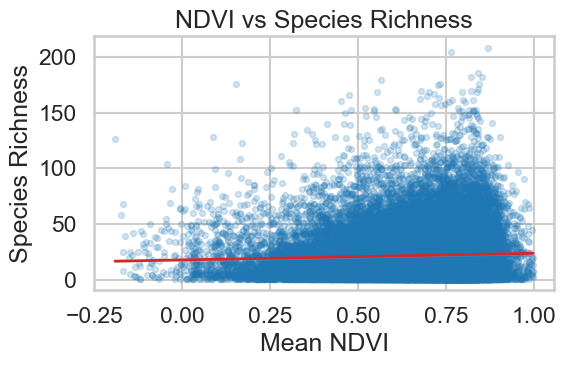

In [53]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.regplot(
    data=bio,
    x="mean_ndvi",
    y="species_richness",
    scatter_kws={"alpha": 0.2, "s": 18, "color": "#1f77b4"},
    line_kws={"color": "#d62728", "linewidth": 2},
    ax=ax
)
ax.set_title("NDVI vs Species Richness")
ax.set_xlabel("Mean NDVI")
ax.set_ylabel("Species Richness")

plt.tight_layout()
plt.show()

##### This scatter plot shows the relationship between mean NDVI (vegetation index) and species richness across sampling units. Each blue point represents a site-month, and the red line is the regression trend. The plot indicates a very weak positive relationship, meaning that sites with higher NDVI tend to have slightly more species, but the effect is small and most points are clustered at lower richness values.

#### 2) NDVI vs Shannon

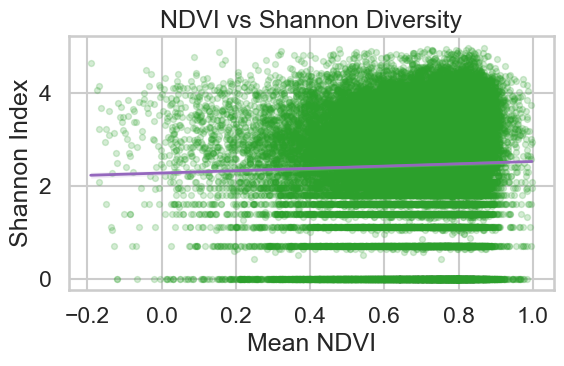

In [54]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.regplot(
    data=bio,
    x="mean_ndvi",
    y="shannon",
    scatter_kws={"alpha": 0.2, "s": 18, "color": "#2ca02c"},
    line_kws={"color": "#9467bd", "linewidth": 2},
    ax=ax
)

ax.set_title("NDVI vs Shannon Diversity")
ax.set_xlabel("Mean NDVI")
ax.set_ylabel("Shannon Index")

plt.tight_layout()
plt.show()

##### This scatter plot shows the relationship between mean NDVI and Shannon diversity across sampling units. Each green point represents a site-month, and the purple line shows the regression trend. The plot indicates a very weak positive relationship, meaning that areas with higher NDVI tend to have slightly higher diversity, but the trend is minimal and most points are concentrated at lower Shannon values.

#### 3) Boxplot: richness by land-cover class

In [55]:
order_rich = bio.groupby("landcover_mode")["species_richness"].median().sort_values(ascending=False).index

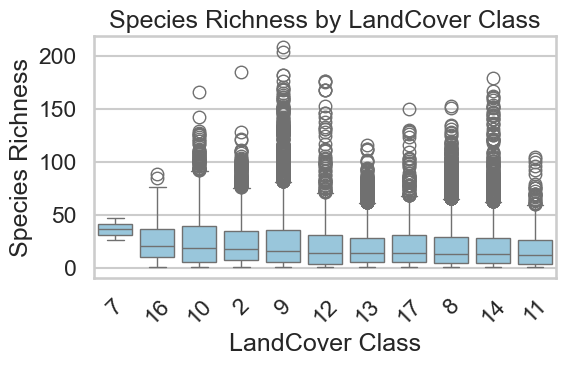

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=bio,
    x="landcover_mode",
    y="species_richness",
    order=order_rich,
    color="#8ecae6",
    ax=ax
)

ax.set_title("Species Richness by LandCover Class")
ax.set_xlabel("LandCover Class")
ax.set_ylabel("Species Richness")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

##### This boxplot shows that species richness varies noticeably across different land cover classes. Some classes (like 7 and 10) tend to have higher median richness, while others (such as 11, 14, and 8) generally show lower typical values. However, there is also a lot of overlap and variability within each class, with many outliers indicating that richness can still be high in less favorable habitats. Overall, the figure suggests that habitat type influences biodiversity, but it is not the only factor, since values vary widely even within the same land cover class.

In [61]:
# The line inside the box = median (middle value)
# The box edges = 25th percentile (Q1) and 75th percentile (Q3)
# So the box shows where the middle 50% of values lie
# The lines (“whiskers”) extending from the box show the typical range of values (excluding extreme ones)

# Circles (dots) represent outliers:
# Values that are much higher or lower than the normal range
# These are unusual or extreme observations

#### 4) Boxplot: Shannon by land-cover class

In [57]:
order_shan = bio.groupby("landcover_mode")["shannon"].median().sort_values(ascending=False).index

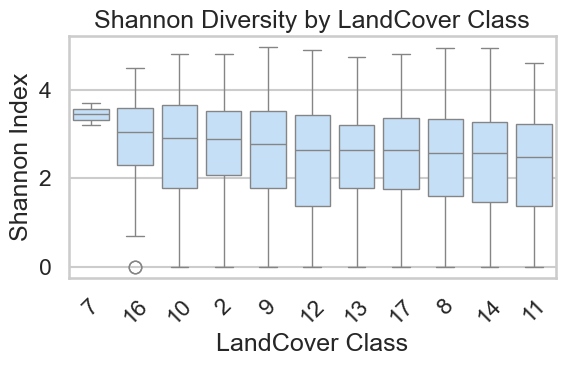

In [58]:
fig, ax = plt.subplots(figsize=(6, 4))

sns.boxplot(
    data=bio,
    x="landcover_mode",
    y="shannon",
    order=order_shan,
    color="#bde0fe",
    ax=ax
)

ax.set_title("Shannon Diversity by LandCover Class")
ax.set_xlabel("LandCover Class")
ax.set_ylabel("Shannon Index")
ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

##### This boxplot shows that Shannon diversity is fairly similar across land cover classes, with most medians around 2–3. Class 1 has a slightly higher median, but overall differences are small. The wide spread indicates high variability within each class, meaning diversity varies even within the same habitat.

### Dunn adjusted p-value heatmaps

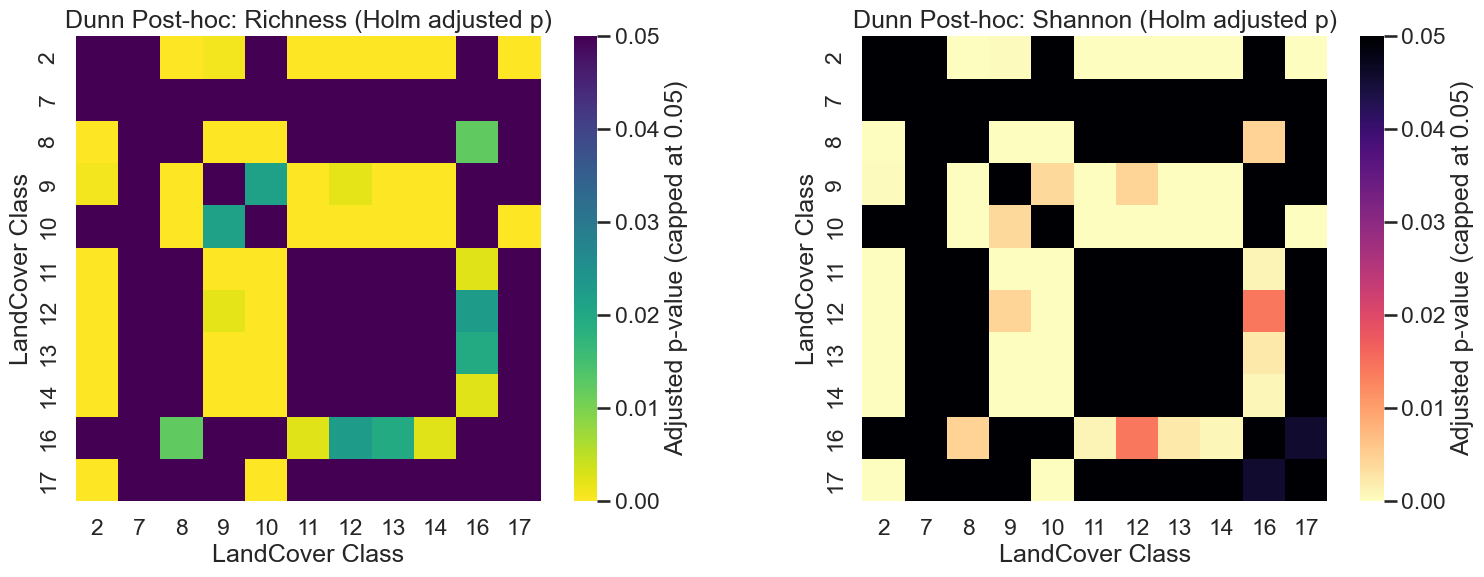

In [59]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(
    rich_dunn,
    cmap="viridis_r",
    vmin=0,
    vmax=0.05,
    square=True,
    cbar_kws={"label": "Adjusted p-value (capped at 0.05)"},
    ax=axes[0]
)
axes[0].set_title("Dunn Post-hoc: Richness (Holm adjusted p)")
axes[0].set_xlabel("LandCover Class")
axes[0].set_ylabel("LandCover Class")

sns.heatmap(
    shan_dunn,
    cmap="magma_r",
    vmin=0,
    vmax=0.05,
    square=True,
    cbar_kws={"label": "Adjusted p-value (capped at 0.05)"},
    ax=axes[1]
)
axes[1].set_title("Dunn Post-hoc: Shannon (Holm adjusted p)")
axes[1].set_xlabel("LandCover Class")
axes[1].set_ylabel("LandCover Class")

plt.tight_layout()
plt.show()